<a href="https://colab.research.google.com/github/ajwitt2-a11y/GB885-Assignment-7-Witt-A/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Sportswear Sales Analysis

**Student:** Aaron Witt  
**Course:** GB885  
**Project:** Final Project  

## Business Problem

RUSH leadership wants to better understand its United States sales performance and identify opportunities for future growth.

This analysis will:

1. Prepare and clean the raw product, retailer, and sales data.
2. Answer the VP of US Sales' four business questions.
3. Examine additional trends involving products, retailers, locations, seasonality, and sales methods.
4. Provide recommendations based on the analysis.

In [1]:
# Import the libraries needed for the project.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Import the file-upload tool from Google Colab.

from google.colab import files


# Upload the three RUSH data files.

uploaded = files.upload()

Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885.csv


In [3]:
# Import the file-upload tool from Google Colab.

from google.colab import files


# Upload the three RUSH data files.

uploaded = files.upload()

Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885.csv


In [10]:
# Import the file-upload tool from Google Colab.

from google.colab import files


# Upload the three RUSH data files.

uploaded = files.upload()

Saving TABLE_SALES_885.csv to TABLE_SALES_885.csv


In [11]:
# Load the product table.
# The product file uses the "|" symbol as its separator.

df_products = pd.read_csv(
    "TABLE_PRODUCTS_885.csv",
    sep="|",
    dtype={"PRODUCT_ID": str}
)


# Display the product table.

df_products

,PRODUCT_ID,PRODUCT_NAME
0,020,Men's Street Footwear
1,030,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,040,Men's Apparel
5,140,Women's Apparel


In [12]:
# Load the retailer table.

df_retailers = pd.read_csv(
    "TABLE_RETAILER_885.csv",
    dtype={"RETAILER_ID": str}
)


# Display the first five rows.

df_retailers.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [13]:
# Load the sales table.
# Product and retailer IDs are loaded as text values.

df_sales = pd.read_csv(
    "TABLE_SALES_885.csv",
    dtype={
        "RETAILER_ID": str,
        "PRODUCT_ID": str
    }
)


# Display the first five rows.

df_sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,020,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,020,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,020,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,020,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,020,60.0,1220,0.5,Outlet


# Data Inspection

The data will be inspected for:

- Incorrect dimensions
- Incorrect data types
- Missing values
- Duplicate rows
- Duplicate primary keys
- Inconsistent spelling
- Invalid identifiers
- Invalid numeric values
- Unusual outliers

In [14]:
# Display the dimensions of each dataframe.

print("Product table dimensions:", df_products.shape)
print("Retailer table dimensions:", df_retailers.shape)
print("Sales table dimensions:", df_sales.shape)

Product table dimensions: (6, 2)
Retailer table dimensions: (110, 5)
Sales table dimensions: (9648, 11)


In [15]:
# Display the column names in each dataframe.

print("Product columns:")
print(df_products.columns.tolist())

print("\nRetailer columns:")
print(df_retailers.columns.tolist())

print("\nSales columns:")
print(df_sales.columns.tolist())

Product columns:
['PRODUCT_ID', 'PRODUCT_NAME']

Retailer columns:
['RETAILER_ID', 'RETAILER', 'REGION', 'STATE', 'CITY']

Sales columns:
['ORDER_ID', 'RETAILER_ID', 'INVOICE_DATE', 'MONTH', 'DAY', 'YEAR', 'PRODUCT_ID', 'PRICE_PER_UNIT', 'UNITS_SOLD', 'OPERATING_MARGIN', 'SALES_METHOD']


In [16]:
# Display the data types in each dataframe.

print("PRODUCT DATA TYPES")
print(df_products.dtypes)

print("\nRETAILER DATA TYPES")
print(df_retailers.dtypes)

print("\nSALES DATA TYPES")
print(df_sales.dtypes)

PRODUCT DATA TYPES
PRODUCT_ID      object
PRODUCT_NAME    object
dtype: object

RETAILER DATA TYPES
RETAILER_ID    object
RETAILER       object
REGION         object
STATE          object
CITY           object
dtype: object

SALES DATA TYPES
ORDER_ID              int64
RETAILER_ID          object
INVOICE_DATE         object
MONTH                 int64
DAY                   int64
YEAR                  int64
PRODUCT_ID           object
PRICE_PER_UNIT      float64
UNITS_SOLD           object
OPERATING_MARGIN    float64
SALES_METHOD         object
dtype: object


In [17]:
# Display the first five rows of the product table.

df_products.head()

,PRODUCT_ID,PRODUCT_NAME
0,020,Men's Street Footwear
1,030,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,040,Men's Apparel


In [18]:
# Display the first five rows of the retailer table.

df_retailers.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [19]:
# Display the first five rows of the sales table.

df_sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,020,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,020,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,020,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,020,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,020,60.0,1220,0.5,Outlet


In [20]:
# Count missing values in the product table.

print("MISSING PRODUCT VALUES")
print(df_products.isna().sum())


# Count missing values in the retailer table.

print("\nMISSING RETAILER VALUES")
print(df_retailers.isna().sum())


# Count missing values in the sales table.

print("\nMISSING SALES VALUES")
print(df_sales.isna().sum())

MISSING PRODUCT VALUES
PRODUCT_ID      0
PRODUCT_NAME    0
dtype: int64

MISSING RETAILER VALUES
RETAILER_ID    0
RETAILER       0
REGION         0
STATE          0
CITY           0
dtype: int64

MISSING SALES VALUES
ORDER_ID            0
RETAILER_ID         0
INVOICE_DATE        0
MONTH               0
DAY                 0
YEAR                0
PRODUCT_ID          0
PRICE_PER_UNIT      2
UNITS_SOLD          0
OPERATING_MARGIN    0
SALES_METHOD        0
dtype: int64


In [21]:
# Count completely duplicated rows in each dataframe.

print("Duplicate product rows:", df_products.duplicated().sum())
print("Duplicate retailer rows:", df_retailers.duplicated().sum())
print("Duplicate sales rows:", df_sales.duplicated().sum())

Duplicate product rows: 0
Duplicate retailer rows: 0
Duplicate sales rows: 0


In [22]:
# Check for duplicate product IDs.

duplicate_product_ids = df_products[
    df_products.duplicated(
        subset="PRODUCT_ID",
        keep=False
    )
]

print("Duplicate product IDs:")
display(duplicate_product_ids)


# Check for duplicate retailer IDs.

duplicate_retailer_ids = df_retailers[
    df_retailers.duplicated(
        subset="RETAILER_ID",
        keep=False
    )
].sort_values("RETAILER_ID")

print("\nDuplicate retailer IDs:")
display(duplicate_retailer_ids)


# Check for duplicate order IDs.

duplicate_order_ids = df_sales[
    df_sales.duplicated(
        subset="ORDER_ID",
        keep=False
    )
]

print("\nDuplicate order IDs:")
display(duplicate_order_ids)

Duplicate product IDs:


,PRODUCT_ID,PRODUCT_NAME



Duplicate retailer IDs:


,RETAILER_ID,RETAILER,REGION,STATE,CITY
63,S00NNENE,Sports Direct,Northeast,New Jersey,Newark
64,S00NNENE,Sports Direct,Northeast,New York,New York
81,W00SARLI,Walmart,South,Arkansas,Little Rock
97,W00SARLI,West Gear,South,Arkansas,Little Rock
84,W00SFLOR,Walmart,Southeast,Florida,Orlando
102,W00SFLOR,West Gear,Southeast,Florida,Orlando
83,W00STEHO,Walmart,South,Texas,Houston
100,W00STEHO,West Gear,South,Texas,Houston



Duplicate order IDs:


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD


In [23]:
# Display all sales method values and their frequencies.

df_sales["SALES_METHOD"].value_counts(dropna=False)

,count
SALES_METHOD,
Online,4889
Outlet,2999
In-store,1740
Ootlet,20


In [24]:
# Convert units sold to numeric temporarily.
# Invalid values will become missing values.

units_numeric_test = pd.to_numeric(
    df_sales["UNITS_SOLD"],
    errors="coerce"
)


# Display rows with invalid units-sold values.

invalid_units = df_sales[
    units_numeric_test.isna()
]

invalid_units

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1012,6064,S00SALBI,5/27/2021,5,27,2021,020,51.0,***,0.45,Online
1439,8626,W00MIODE,12/10/2021,12,10,2021,020,29.0,***,0.46,Outlet


In [25]:
# Display descriptive statistics for price per unit.

df_sales["PRICE_PER_UNIT"].describe()

,PRICE_PER_UNIT
count,9646.000000
mean,55.575264
std,1017.819943
min,7.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,99999.000000


In [26]:
# Display rows with missing prices.

print("ROWS WITH MISSING PRICES")
display(
    df_sales[
        df_sales["PRICE_PER_UNIT"].isna()
    ]
)


# Display unusually high prices.

print("ROWS WITH PRICES ABOVE $1,000")
display(
    df_sales[
        df_sales["PRICE_PER_UNIT"] > 1000
    ]
)

ROWS WITH MISSING PRICES


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
98,591,A00NVEBU,4/2/2020,4,2,2020,020,NaN,525,0.35,In-store
99,597,A00NVEBU,4/8/2020,4,8,2020,020,NaN,525,0.50,In-store


ROWS WITH PRICES ABOVE $1,000


,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
423,2536,F00NNEMA,5/23/2021,5,23,2021,020,99999.0,520,0.4,Online


In [27]:
# Identify sales records whose retailer ID is not found
# in the retailer table.

invalid_retailer_ids = df_sales[
    ~df_sales["RETAILER_ID"].isin(
        df_retailers["RETAILER_ID"]
    )
]

invalid_retailer_ids

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,7/23/2021,7,23,2021,020,60.0,298,0.42,Outlet


In [28]:
# Convert invoice dates temporarily to datetime values.

date_test = pd.to_datetime(
    df_sales["INVOICE_DATE"],
    errors="coerce"
)


# Count dates that could not be converted.

print("Invalid invoice dates:", date_test.isna().sum())


# Check whether the date components match
# the separate month, day, and year columns.

print(
    "Year mismatches:",
    (date_test.dt.year != df_sales["YEAR"]).sum()
)

print(
    "Month mismatches:",
    (date_test.dt.month != df_sales["MONTH"]).sum()
)

print(
    "Day mismatches:",
    (date_test.dt.day != df_sales["DAY"]).sum()
)

Invalid invoice dates: 0
Year mismatches: 0
Month mismatches: 0
Day mismatches: 0


## Data Inspection Findings

The inspection identified the following data-quality issues:

1. The product table uses a vertical bar instead of a comma as its separator.
2. Product IDs must retain their leading zeros.
3. Two sales records have missing prices.
4. Two units-sold values contain "***" instead of numbers.
5. One price-per-unit value is $99,999 and appears to be a data-entry error.
6. Twenty sales-method values are misspelled as "Ootlet."
7. One sales record has a retailer ID that is not present in the retailer table.
8. Four retailer IDs appear more than once in the retailer table.
9. Invoice dates were initially stored as text.
10. No completely duplicated sales rows were found.

In [30]:
# Create copies so the original raw data remains unchanged.

products_clean = df_products.copy()
retailers_clean = df_retailers.copy()
sales_clean = df_sales.copy()

In [31]:
# Remove unnecessary spaces from column names
# and convert the names to uppercase.

products_clean.columns = (
    products_clean.columns
    .str.strip()
    .str.upper()
)

retailers_clean.columns = (
    retailers_clean.columns
    .str.strip()
    .str.upper()
)

sales_clean.columns = (
    sales_clean.columns
    .str.strip()
    .str.upper()
)

In [32]:
# Remove spaces and make all product IDs three digits long.

products_clean["PRODUCT_ID"] = (
    products_clean["PRODUCT_ID"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)


sales_clean["PRODUCT_ID"] = (
    sales_clean["PRODUCT_ID"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)

In [33]:
# Remove leading and trailing spaces from product names.

products_clean["PRODUCT_NAME"] = (
    products_clean["PRODUCT_NAME"]
    .str.strip()
)


# Remove spaces from retailer text fields.

retailer_text_columns = [
    "RETAILER_ID",
    "RETAILER",
    "REGION",
    "STATE",
    "CITY"
]

for column in retailer_text_columns:
    retailers_clean[column] = (
        retailers_clean[column]
        .str.strip()
    )


# Remove spaces from sales text fields.

sales_clean["RETAILER_ID"] = (
    sales_clean["RETAILER_ID"]
    .str.strip()
)

sales_clean["SALES_METHOD"] = (
    sales_clean["SALES_METHOD"]
    .str.strip()
)

In [34]:
# Correct the misspelled sales method.

sales_clean["SALES_METHOD"] = (
    sales_clean["SALES_METHOD"]
    .replace({
        "Ootlet": "Outlet"
    })
)


# Confirm the corrected values.

sales_clean["SALES_METHOD"].value_counts()

,count
SALES_METHOD,
Online,4889
Outlet,3019
In-store,1740


In [35]:
# Convert invoice date from text to a datetime value.

sales_clean["INVOICE_DATE"] = pd.to_datetime(
    sales_clean["INVOICE_DATE"],
    errors="coerce"
)


# Confirm the new data type.

sales_clean["INVOICE_DATE"].dtype

dtype('<M8[ns]')

In [36]:
# Convert units sold to numeric.
# Values such as "***" become missing values.

sales_clean["UNITS_SOLD"] = pd.to_numeric(
    sales_clean["UNITS_SOLD"],
    errors="coerce"
)


# Count missing units after conversion.

sales_clean["UNITS_SOLD"].isna().sum()

np.int64(2)

In [37]:
# Record the number of rows before cleaning.

rows_before_cleaning = len(sales_clean)


# Remove rows missing required sales values.

sales_clean = sales_clean.dropna(
    subset=[
        "PRICE_PER_UNIT",
        "UNITS_SOLD",
        "INVOICE_DATE"
    ]
)


# Remove the unreasonable $99,999 price.
# Valid prices in the data are well below $1,000.

sales_clean = sales_clean[
    sales_clean["PRICE_PER_UNIT"] < 1000
]


# Remove sales records whose retailer ID is not
# found in the retailer table.

sales_clean = sales_clean[
    sales_clean["RETAILER_ID"].isin(
        retailers_clean["RETAILER_ID"]
    )
]


# Record the number of rows after cleaning.

rows_after_cleaning = len(sales_clean)


print("Rows before cleaning:", rows_before_cleaning)
print("Rows after cleaning:", rows_after_cleaning)
print(
    "Rows removed:",
    rows_before_cleaning - rows_after_cleaning
)

Rows before cleaning: 9648
Rows after cleaning: 9642
Rows removed: 6


In [38]:
# Remove repeated retailer IDs before merging.
# The first record for each retailer ID will be retained.
# This prevents one sales row from matching multiple retailer rows.

retailers_clean = retailers_clean.drop_duplicates(
    subset="RETAILER_ID",
    keep="first"
)


# Confirm that retailer IDs are now unique.

print(
    "Duplicate retailer IDs remaining:",
    retailers_clean["RETAILER_ID"].duplicated().sum()
)

Duplicate retailer IDs remaining: 0


In [39]:
# Remove any completely duplicated rows.

products_clean = products_clean.drop_duplicates()
retailers_clean = retailers_clean.drop_duplicates()
sales_clean = sales_clean.drop_duplicates()

In [40]:
# Merge the sales table with the product table.

rush_data = sales_clean.merge(
    products_clean,
    on="PRODUCT_ID",
    how="left",
    validate="many_to_one"
)


# Display the first five rows.

rush_data.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME
0,1,A00MOHCO,2020-01-01,1,1,2020,020,50.0,1200.0,0.5,In-store,Men's Street Footwear
1,7,A00MOHCO,2020-01-07,1,7,2020,020,50.0,1250.0,0.5,In-store,Men's Street Footwear
2,13,A00MOHCO,2020-01-25,1,25,2020,020,50.0,1220.0,0.5,Outlet,Men's Street Footwear
3,19,A00MOHCO,2020-01-31,1,31,2020,020,50.0,1200.0,0.5,Outlet,Men's Street Footwear
4,25,A00MOHCO,2020-02-06,2,6,2020,020,60.0,1220.0,0.5,Outlet,Men's Street Footwear


In [41]:
# Add retailer and location information.

rush_data = rush_data.merge(
    retailers_clean,
    on="RETAILER_ID",
    how="left",
    validate="many_to_one"
)


# Display the first five rows.

rush_data.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,PRODUCT_NAME,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,2020-01-01,1,1,2020,020,50.0,1200.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,2020-01-07,1,7,2020,020,50.0,1250.0,0.5,In-store,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,2020-01-25,1,25,2020,020,50.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,2020-01-31,1,31,2020,020,50.0,1200.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2020-02-06,2,6,2020,020,60.0,1220.0,0.5,Outlet,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus


In [42]:
# Calculate total sales revenue for every order.

rush_data["TOTAL_SALES"] = (
    rush_data["PRICE_PER_UNIT"]
    * rush_data["UNITS_SOLD"]
)


# Display selected columns.

rush_data[
    [
        "ORDER_ID",
        "PRICE_PER_UNIT",
        "UNITS_SOLD",
        "TOTAL_SALES"
    ]
].head()

,ORDER_ID,PRICE_PER_UNIT,UNITS_SOLD,TOTAL_SALES
0,1,50.0,1200.0,60000.0
1,7,50.0,1250.0,62500.0
2,13,50.0,1220.0,61000.0
3,19,50.0,1200.0,60000.0
4,25,60.0,1220.0,73200.0


In [43]:
# Create month names for easier interpretation.

rush_data["MONTH_NAME"] = (
    rush_data["INVOICE_DATE"]
    .dt.month_name()
)


# Create a month-year field for time-based analysis.

rush_data["YEAR_MONTH"] = (
    rush_data["INVOICE_DATE"]
    .dt.to_period("M")
    .astype(str)
)

In [44]:
# Display final dimensions.

print("Final dimensions:", rush_data.shape)


# Display missing values.

print("\nMissing values:")
print(rush_data.isna().sum())


# Display final data types.

print("\nFinal data types:")
print(rush_data.dtypes)

Final dimensions: (9642, 19)

Missing values:
ORDER_ID            0
RETAILER_ID         0
INVOICE_DATE        0
MONTH               0
DAY                 0
YEAR                0
PRODUCT_ID          0
PRICE_PER_UNIT      0
UNITS_SOLD          0
OPERATING_MARGIN    0
SALES_METHOD        0
PRODUCT_NAME        0
RETAILER            0
REGION              0
STATE               0
CITY                0
TOTAL_SALES         0
MONTH_NAME          0
YEAR_MONTH          0
dtype: int64

Final data types:
ORDER_ID                     int64
RETAILER_ID                 object
INVOICE_DATE        datetime64[ns]
MONTH                        int64
DAY                          int64
YEAR                         int64
PRODUCT_ID                  object
PRICE_PER_UNIT             float64
UNITS_SOLD                 float64
OPERATING_MARGIN           float64
SALES_METHOD                object
PRODUCT_NAME                object
RETAILER                    object
REGION                      object
STATE         

## Data Cleaning Summary

The cleaning process:

- Preserved product IDs as three-digit text values.
- Corrected "Ootlet" to "Outlet."
- Converted invoice dates to datetime values.
- Converted units sold to numeric values.
- Removed two rows with missing prices.
- Removed two rows with invalid units sold.
- Removed one extreme price outlier.
- Removed one record with an invalid retailer ID.
- Resolved duplicate retailer IDs before merging.
- Combined all three tables.
- Calculated total sales as price per unit multiplied by units sold.

The final combined dataset contains 9,642 valid sales records.

# VP Business Questions

## Question 1

What product category had the highest sales in dollars in 2021, and how much did it sell?

In [45]:
# Filter the data to 2021.

sales_2021 = rush_data[
    rush_data["YEAR"] == 2021
]


# Calculate total sales by product category.

product_sales_2021 = (
    sales_2021
    .groupby(
        "PRODUCT_NAME",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


# Format sales for display.

product_sales_2021["TOTAL_SALES_FORMATTED"] = (
    product_sales_2021["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


product_sales_2021

,PRODUCT_NAME,TOTAL_SALES,TOTAL_SALES_FORMATTED
2,Men's Street Footwear,22631520.0,"$22,631,520.00"
3,Women's Apparel,19178278.0,"$19,178,278.00"
1,Men's Athletic Footwear,16339593.0,"$16,339,593.00"
5,Women's Street Footwear,13535783.0,"$13,535,783.00"
0,Men's Apparel,13025293.0,"$13,025,293.00"
4,Women's Athletic Footwear,11160629.0,"$11,160,629.00"


In [46]:
# Select the product with the highest sales.

highest_product_2021 = product_sales_2021.iloc[0]


print(
    "Highest-selling product category:",
    highest_product_2021["PRODUCT_NAME"]
)

print(
    "Total 2021 sales:",
    highest_product_2021["TOTAL_SALES_FORMATTED"]
)

Highest-selling product category: Men's Street Footwear
Total 2021 sales: $22,631,520.00


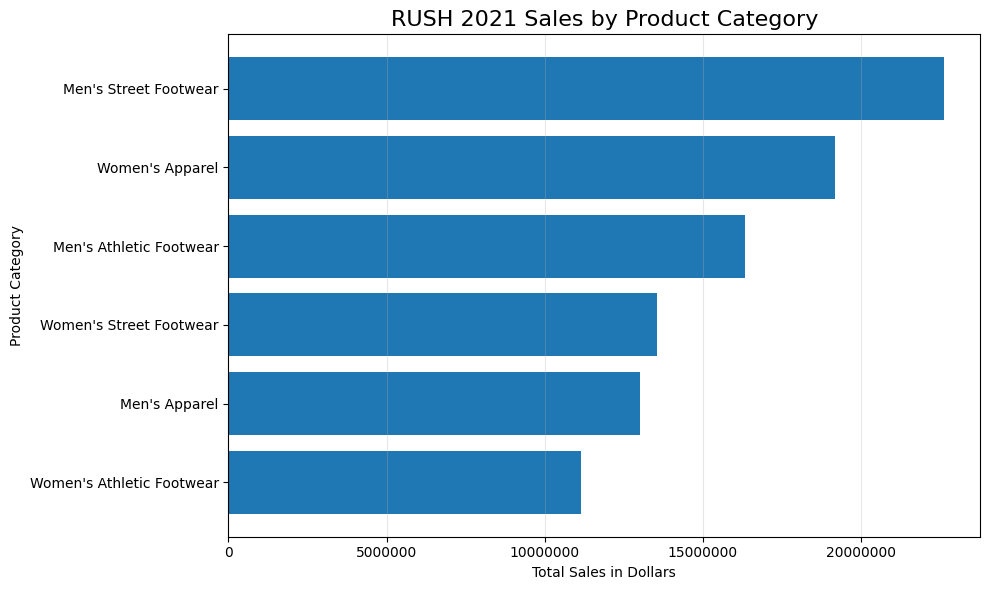

In [47]:
# Create a horizontal bar chart of 2021 sales by product.

product_chart_data = (
    product_sales_2021
    .sort_values(
        "TOTAL_SALES",
        ascending=True
    )
)


plt.figure(figsize=(10, 6))

plt.barh(
    product_chart_data["PRODUCT_NAME"],
    product_chart_data["TOTAL_SALES"]
)

plt.title(
    "RUSH 2021 Sales by Product Category",
    fontsize=16
)

plt.xlabel("Total Sales in Dollars")
plt.ylabel("Product Category")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Question 2

What state had the highest sales in dollars of women's products in 2021, and how much was it?

In [48]:
# Create a dataframe containing only women's products sold in 2021.

womens_sales_2021 = rush_data[
    (rush_data["YEAR"] == 2021)
    &
    (
        rush_data["PRODUCT_NAME"]
        .str.startswith("Women's")
    )
]


# Display the product names included.

womens_sales_2021[
    "PRODUCT_NAME"
].unique()

array(["Women's Street Footwear", "Women's Athletic Footwear",
       "Women's Apparel"], dtype=object)

In [49]:
# Calculate women's product sales by state.

womens_state_sales = (
    womens_sales_2021
    .groupby(
        "STATE",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


# Add a formatted sales column.

womens_state_sales["TOTAL_SALES_FORMATTED"] = (
    womens_state_sales["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


womens_state_sales.head(10)

,STATE,TOTAL_SALES,TOTAL_SALES_FORMATTED
18,Maine,2176301.0,"$2,176,301.00"
7,Delaware,2023575.0,"$2,023,575.00"
28,New Hampshire,1916400.0,"$1,916,400.00"
2,Arizona,1798900.0,"$1,798,900.00"
24,Missouri,1771992.0,"$1,771,992.00"
12,Illinois,1743277.0,"$1,743,277.00"
45,Virginia,1719886.0,"$1,719,886.00"
26,Nebraska,1712680.0,"$1,712,680.00"
6,Connecticut,1600156.0,"$1,600,156.00"
31,New York,1505256.0,"$1,505,256.00"


In [50]:
# Select the state with the highest women's product sales.

highest_womens_state = womens_state_sales.iloc[0]


print(
    "Top state for women's products:",
    highest_womens_state["STATE"]
)

print(
    "Total 2021 women's sales:",
    highest_womens_state["TOTAL_SALES_FORMATTED"]
)

Top state for women's products: Maine
Total 2021 women's sales: $2,176,301.00


## Question 3

What state had the highest sales in dollars of men's products in 2021, and how much was it?

In [51]:
# Create a dataframe containing only men's products sold in 2021.

mens_sales_2021 = rush_data[
    (rush_data["YEAR"] == 2021)
    &
    (
        rush_data["PRODUCT_NAME"]
        .str.startswith("Men's")
    )
]


# Display the product names included.

mens_sales_2021[
    "PRODUCT_NAME"
].unique()

array(["Men's Street Footwear", "Men's Athletic Footwear",
       "Men's Apparel"], dtype=object)

In [52]:
# Calculate men's product sales by state.

mens_state_sales = (
    mens_sales_2021
    .groupby(
        "STATE",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


# Add a formatted sales column.

mens_state_sales["TOTAL_SALES_FORMATTED"] = (
    mens_state_sales["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


mens_state_sales.head(10)

,STATE,TOTAL_SALES,TOTAL_SALES_FORMATTED
7,Delaware,2334300.0,"$2,334,300.00"
2,Arizona,2261025.0,"$2,261,025.00"
18,Maine,2217190.0,"$2,217,190.00"
28,New Hampshire,2208600.0,"$2,208,600.00"
12,Illinois,2093438.0,"$2,093,438.00"
24,Missouri,1951530.0,"$1,951,530.00"
6,Connecticut,1926568.0,"$1,926,568.00"
31,New York,1847069.0,"$1,847,069.00"
26,Nebraska,1718726.0,"$1,718,726.00"
30,New Mexico,1708196.0,"$1,708,196.00"


In [53]:
# Select the state with the highest men's product sales.

highest_mens_state = mens_state_sales.iloc[0]


print(
    "Top state for men's products:",
    highest_mens_state["STATE"]
)

print(
    "Total 2021 men's sales:",
    highest_mens_state["TOTAL_SALES_FORMATTED"]
)

Top state for men's products: Delaware
Total 2021 men's sales: $2,334,300.00


## Question 4

What retailer purchased the most units in 2021? What retailer purchased the most units in 2020?

In [54]:
# Calculate total units sold to each retailer in 2021.

retailer_units_2021 = (
    rush_data[
        rush_data["YEAR"] == 2021
    ]
    .groupby(
        "RETAILER",
        as_index=False
    )
    .agg(
        UNITS_SOLD=("UNITS_SOLD", "sum")
    )
    .sort_values(
        "UNITS_SOLD",
        ascending=False
    )
)


retailer_units_2021

,RETAILER,UNITS_SOLD
1,Foot Locker,1096890.0
5,West Gear,269486.0
3,Sports Direct,248131.0
0,Amazon,205570.0
2,Kohl's,136950.0
4,Walmart,58286.0


In [55]:
# Select the retailer with the most units in 2021.

top_retailer_2021 = retailer_units_2021.iloc[0]


print(
    "Top retailer in 2021:",
    top_retailer_2021["RETAILER"]
)

print(
    "Units purchased:",
    f'{top_retailer_2021["UNITS_SOLD"]:,.0f}'
)

Top retailer in 2021: Foot Locker
Units purchased: 1,096,890


In [56]:
# Calculate total units sold to each retailer in 2020.

retailer_units_2020 = (
    rush_data[
        rush_data["YEAR"] == 2020
    ]
    .groupby(
        "RETAILER",
        as_index=False
    )
    .agg(
        UNITS_SOLD=("UNITS_SOLD", "sum")
    )
    .sort_values(
        "UNITS_SOLD",
        ascending=False
    )
)


retailer_units_2020

,RETAILER,UNITS_SOLD
0,Amazon,316880.0
1,Kohl's,68686.0
3,West Gear,57334.0
2,Sports Direct,18399.0


In [57]:
# Select the retailer with the most units in 2020.

top_retailer_2020 = retailer_units_2020.iloc[0]


print(
    "Top retailer in 2020:",
    top_retailer_2020["RETAILER"]
)

print(
    "Units purchased:",
    f'{top_retailer_2020["UNITS_SOLD"]:,.0f}'
)

Top retailer in 2020: Amazon
Units purchased: 316,880


In [58]:
# Combine yearly retailer unit totals.

retailer_year_comparison = (
    rush_data[
        rush_data["YEAR"].isin(
            [2020, 2021]
        )
    ]
    .groupby(
        [
            "RETAILER",
            "YEAR"
        ],
        as_index=False
    )
    .agg(
        UNITS_SOLD=("UNITS_SOLD", "sum")
    )
)


# Reshape the data for comparison.

retailer_year_pivot = (
    retailer_year_comparison
    .pivot(
        index="RETAILER",
        columns="YEAR",
        values="UNITS_SOLD"
    )
    .fillna(0)
)


retailer_year_pivot

YEAR,2020,2021
RETAILER,,
Amazon,316880.0,205570.0
Foot Locker,0.0,1096890.0
Kohl's,68686.0,136950.0
Sports Direct,18399.0,248131.0
Walmart,0.0,58286.0
West Gear,57334.0,269486.0


## Additional Insight 1: Annual Sales Growth

This analysis compares total sales between 2020 and 2021.

In [59]:
# Calculate total sales by year.

annual_sales = (
    rush_data
    .groupby(
        "YEAR",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
)


annual_sales["TOTAL_SALES_FORMATTED"] = (
    annual_sales["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


annual_sales

,YEAR,TOTAL_SALES,TOTAL_SALES_FORMATTED
0,2020,24174325.0,"$24,174,325.00"
1,2021,95871096.0,"$95,871,096.00"


In [60]:
# Extract yearly sales totals.

sales_2020_total = annual_sales.loc[
    annual_sales["YEAR"] == 2020,
    "TOTAL_SALES"
].iloc[0]

sales_2021_total = annual_sales.loc[
    annual_sales["YEAR"] == 2021,
    "TOTAL_SALES"
].iloc[0]


# Calculate percentage growth.

sales_growth_rate = (
    (
        sales_2021_total
        - sales_2020_total
    )
    / sales_2020_total
) * 100


print(
    "2020 total sales:",
    f"${sales_2020_total:,.2f}"
)

print(
    "2021 total sales:",
    f"${sales_2021_total:,.2f}"
)

print(
    "Sales growth:",
    f"{sales_growth_rate:.1f}%"
)

2020 total sales: $24,174,325.00
2021 total sales: $95,871,096.00
Sales growth: 296.6%


## Additional Insight 2: Sales Performance by Sales Method

This analysis compares online, outlet, and in-store sales during 2021.

In [61]:
# Calculate sales and units by sales method in 2021.

sales_method_2021 = (
    rush_data[
        rush_data["YEAR"] == 2021
    ]
    .groupby(
        "SALES_METHOD",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum"),
        UNITS_SOLD=("UNITS_SOLD", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


sales_method_2021["TOTAL_SALES_FORMATTED"] = (
    sales_method_2021["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


sales_method_2021

,SALES_METHOD,TOTAL_SALES,UNITS_SOLD,TOTAL_SALES_FORMATTED
1,Online,40412041.0,851338.0,"$40,412,041.00"
2,Outlet,29184980.0,630560.0,"$29,184,980.00"
0,In-store,26274075.0,533415.0,"$26,274,075.00"


In [62]:
# Calculate each sales method's share of 2021 sales.

sales_method_2021["SALES_SHARE_PERCENT"] = (
    sales_method_2021["TOTAL_SALES"]
    / sales_method_2021["TOTAL_SALES"].sum()
    * 100
)


sales_method_2021[
    [
        "SALES_METHOD",
        "TOTAL_SALES_FORMATTED",
        "SALES_SHARE_PERCENT"
    ]
]

,SALES_METHOD,TOTAL_SALES_FORMATTED,SALES_SHARE_PERCENT
1,Online,"$40,412,041.00",42.152476
2,Outlet,"$29,184,980.00",30.441897
0,In-store,"$26,274,075.00",27.405627


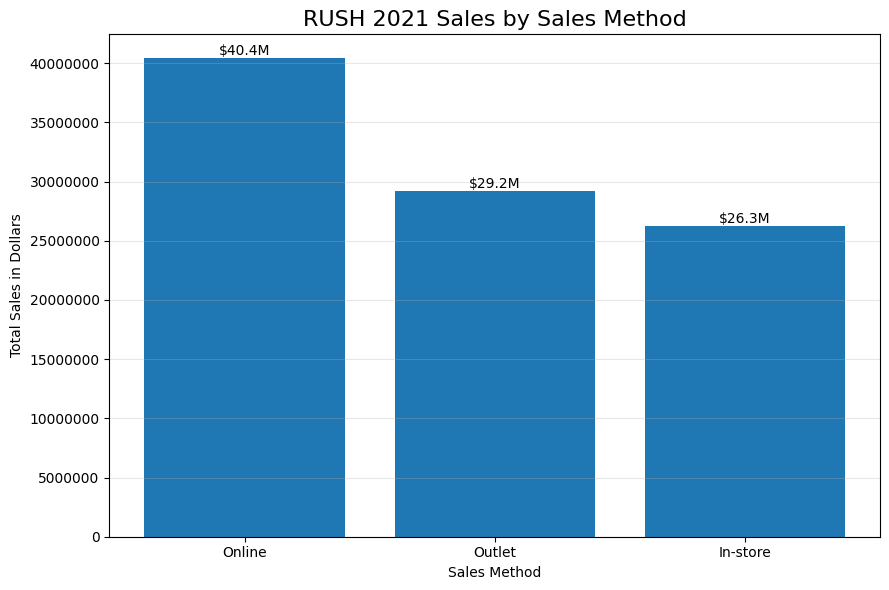

In [63]:
# Create a bar chart of 2021 sales by sales method.

plt.figure(figsize=(9, 6))

bars = plt.bar(
    sales_method_2021["SALES_METHOD"],
    sales_method_2021["TOTAL_SALES"]
)

plt.title(
    "RUSH 2021 Sales by Sales Method",
    fontsize=16
)

plt.xlabel("Sales Method")
plt.ylabel("Total Sales in Dollars")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Add dollar labels above the bars.

for bar in bars:
    bar_height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height,
        f"${bar_height / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

## Additional Insight 3: Regional Sales Performance

This analysis identifies the strongest and weakest sales regions during 2021.

In [64]:
# Calculate 2021 sales by region.

regional_sales_2021 = (
    rush_data[
        rush_data["YEAR"] == 2021
    ]
    .groupby(
        "REGION",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


regional_sales_2021["TOTAL_SALES_FORMATTED"] = (
    regional_sales_2021["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


regional_sales_2021

,REGION,TOTAL_SALES,TOTAL_SALES_FORMATTED
1,Northeast,31716464.0,"$31,716,464.00"
0,Midwest,24799271.0,"$24,799,271.00"
4,West,20951383.0,"$20,951,383.00"
3,Southeast,9368116.0,"$9,368,116.00"
2,South,9035862.0,"$9,035,862.00"


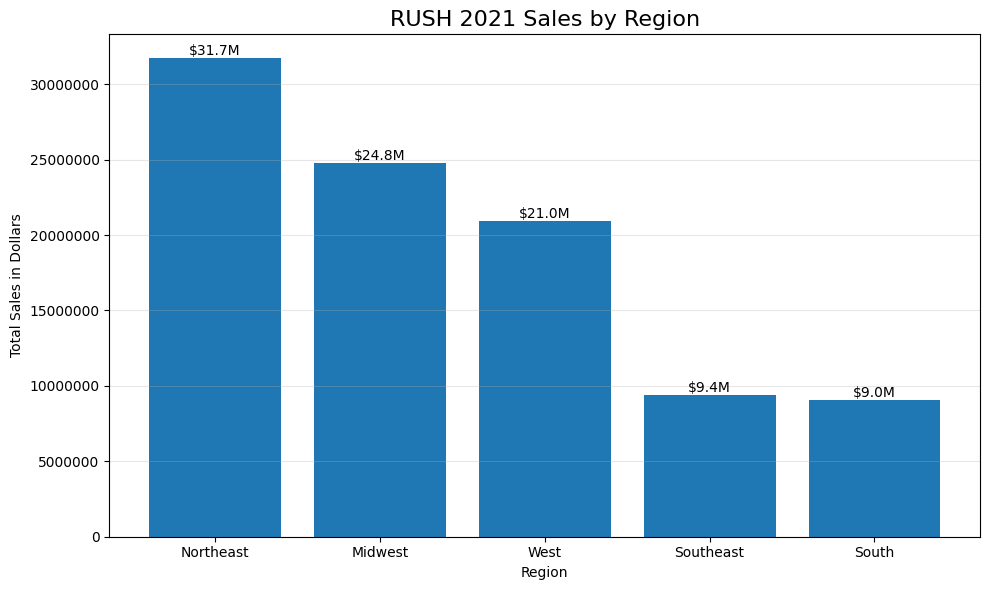

In [65]:
# Create a bar chart of sales by region.

plt.figure(figsize=(10, 6))

bars = plt.bar(
    regional_sales_2021["REGION"],
    regional_sales_2021["TOTAL_SALES"]
)

plt.title(
    "RUSH 2021 Sales by Region",
    fontsize=16
)

plt.xlabel("Region")
plt.ylabel("Total Sales in Dollars")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.grid(
    axis="y",
    alpha=0.3
)


# Add sales labels above each bar.

for bar in bars:
    bar_height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar_height,
        f"${bar_height / 1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()

## Additional Insight 4: Monthly Sales Trends

This analysis evaluates whether RUSH experienced noticeable sales seasonality during 2021.

In [66]:
# Calculate total sales by month in 2021.

monthly_sales_2021 = (
    rush_data[
        rush_data["YEAR"] == 2021
    ]
    .groupby(
        "MONTH",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values("MONTH")
)


# Add month names.

monthly_sales_2021["MONTH_NAME"] = pd.to_datetime(
    monthly_sales_2021["MONTH"],
    format="%m"
).dt.month_name()


monthly_sales_2021

,MONTH,TOTAL_SALES,MONTH_NAME
0,1,7432021.0,January
1,2,6123040.0,February
2,3,5220782.0,March
3,4,6498339.0,April
4,5,8543306.0,May
5,6,8718953.0,June
6,7,10350151.0,July
7,8,9651596.0,August
8,9,8037898.0,September
9,10,7110189.0,October


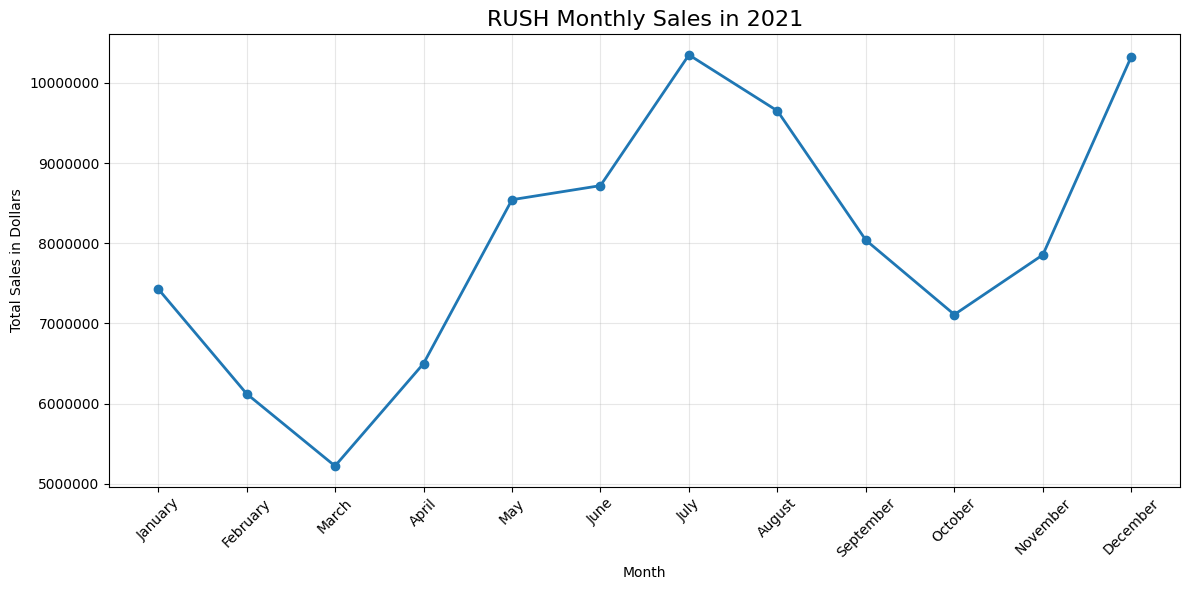

In [67]:
# Create a line graph of monthly sales.

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales_2021["MONTH_NAME"],
    monthly_sales_2021["TOTAL_SALES"],
    marker="o",
    linewidth=2
)

plt.title(
    "RUSH Monthly Sales in 2021",
    fontsize=16
)

plt.xlabel("Month")
plt.ylabel("Total Sales in Dollars")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# Identify the strongest sales month.

top_month = monthly_sales_2021.loc[
    monthly_sales_2021["TOTAL_SALES"].idxmax()
]


print(
    "Highest-sales month:",
    top_month["MONTH_NAME"]
)

print(
    "Total sales:",
    f'${top_month["TOTAL_SALES"]:,.2f}'
)

Highest-sales month: July
Total sales: $10,350,151.00


## Additional Insight 5: Retailer Sales Performance

This analysis compares the total sales revenue generated by each retailer in 2021.

In [69]:
# Calculate total 2021 sales by retailer.

retailer_sales_2021 = (
    rush_data[
        rush_data["YEAR"] == 2021
    ]
    .groupby(
        "RETAILER",
        as_index=False
    )
    .agg(
        TOTAL_SALES=("TOTAL_SALES", "sum")
    )
    .sort_values(
        "TOTAL_SALES",
        ascending=False
    )
)


retailer_sales_2021["TOTAL_SALES_FORMATTED"] = (
    retailer_sales_2021["TOTAL_SALES"]
    .map("${:,.2f}".format)
)


retailer_sales_2021

,RETAILER,TOTAL_SALES,TOTAL_SALES_FORMATTED
1,Foot Locker,53620425.0,"$53,620,425.00"
3,Sports Direct,11630639.0,"$11,630,639.00"
5,West Gear,10641952.0,"$10,641,952.00"
0,Amazon,10487475.0,"$10,487,475.00"
2,Kohl's,7234082.0,"$7,234,082.00"
4,Walmart,2256523.0,"$2,256,523.00"


In [70]:
# Calculate each retailer's share of 2021 sales.

retailer_sales_2021["SALES_SHARE_PERCENT"] = (
    retailer_sales_2021["TOTAL_SALES"]
    / retailer_sales_2021["TOTAL_SALES"].sum()
    * 100
)


retailer_sales_2021[
    [
        "RETAILER",
        "TOTAL_SALES_FORMATTED",
        "SALES_SHARE_PERCENT"
    ]
]

,RETAILER,TOTAL_SALES_FORMATTED,SALES_SHARE_PERCENT
1,Foot Locker,"$53,620,425.00",55.929709
3,Sports Direct,"$11,630,639.00",12.131539
5,West Gear,"$10,641,952.00",11.100272
0,Amazon,"$10,487,475.00",10.939142
2,Kohl's,"$7,234,082.00",7.545634
4,Walmart,"$2,256,523.00",2.353705


In [71]:
# Calculate each retailer's share of 2021 sales.

retailer_sales_2021["SALES_SHARE_PERCENT"] = (
    retailer_sales_2021["TOTAL_SALES"]
    / retailer_sales_2021["TOTAL_SALES"].sum()
    * 100
)


retailer_sales_2021[
    [
        "RETAILER",
        "TOTAL_SALES_FORMATTED",
        "SALES_SHARE_PERCENT"
    ]
]

,RETAILER,TOTAL_SALES_FORMATTED,SALES_SHARE_PERCENT
1,Foot Locker,"$53,620,425.00",55.929709
3,Sports Direct,"$11,630,639.00",12.131539
5,West Gear,"$10,641,952.00",11.100272
0,Amazon,"$10,487,475.00",10.939142
2,Kohl's,"$7,234,082.00",7.545634
4,Walmart,"$2,256,523.00",2.353705


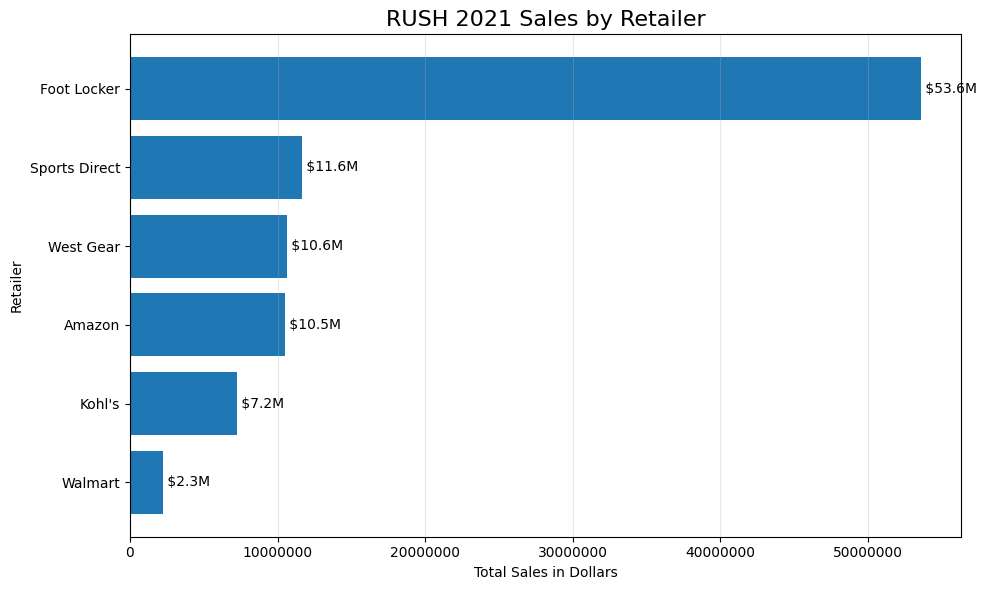

In [72]:
# Create a horizontal bar chart of retailer sales.

retailer_chart_data = (
    retailer_sales_2021
    .sort_values(
        "TOTAL_SALES",
        ascending=True
    )
)


plt.figure(figsize=(10, 6))

bars = plt.barh(
    retailer_chart_data["RETAILER"],
    retailer_chart_data["TOTAL_SALES"]
)

plt.title(
    "RUSH 2021 Sales by Retailer",
    fontsize=16
)

plt.xlabel("Total Sales in Dollars")
plt.ylabel("Retailer")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.grid(
    axis="x",
    alpha=0.3
)


# Add sales labels to the bars.

for bar in bars:
    bar_width = bar.get_width()

    plt.text(
        bar_width,
        bar.get_y() + bar.get_height() / 2,
        f" ${bar_width / 1_000_000:.1f}M",
        va="center"
    )


plt.tight_layout()
plt.show()

# Final Conclusions and Recommendations

## VP Business Question Answers

1. Men's Street Footwear had the highest product sales in 2021, generating $22,631,520.
2. Maine had the highest women's product sales in 2021, generating $2,176,301.
3. Delaware had the highest men's product sales in 2021, generating $2,334,300.
4. Foot Locker purchased the most units in 2021, with 1,096,890 units.
5. Amazon purchased the most units in 2020, with 316,880 units.

## Additional Findings

- Online was the highest-performing sales method in 2021, generating approximately $40.4 million.
- The Northeast was the strongest region, generating approximately $31.7 million.
- July was the strongest sales month, with approximately $10.35 million in sales.
- Foot Locker generated approximately $53.6 million, more than half of 2021 sales.
- Men's Street Footwear was RUSH's strongest product category.

## Recommendations

1. Continue investing in Men's Street Footwear because it is the company's leading product category.
2. Expand digital marketing and online sales capabilities because online was the strongest channel.
3. Examine growth opportunities in the South and Southeast, which underperformed stronger regions.
4. Protect the Foot Locker partnership while expanding other retailer relationships to reduce concentration risk.
5. Prepare inventory and promotions for strong summer and year-end demand.
6. Investigate the data-collection differences between 2020 and 2021 before treating the annual increase as purely organic growth.

In [73]:
# Export the final cleaned and combined dataframe.

rush_data.to_csv(
    "RUSH_CLEANED_SALES_DATA.csv",
    index=False
)


print(
    "The cleaned dataset was successfully exported."
)

The cleaned dataset was successfully exported.


In [74]:
# Download the cleaned dataset from Google Colab.

files.download(
    "RUSH_CLEANED_SALES_DATA.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>